Importing libraries.

In [1]:
import pandas as pd
import numpy as np
import requests
import re
import os
import time
from lxml import html
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

import selenium
from webdriver_manager.chrome import ChromeDriverManager
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait 
from selenium.webdriver.support import expected_conditions as EC 
from selenium.webdriver.common.by import By 
from selenium.webdriver.common.proxy import Proxy, ProxyType

from fake_useragent import UserAgent


Let's define the page we will be scraping.

In [2]:
url = "https://nbp.pl/kategoria/aktualnosci/"

Scraping as a static page.

In [3]:
response = requests.get(url)
response.text

'<html>\r\n<head>\r\n<META NAME="robots" CONTENT="noindex,nofollow">\r\n<script src="/_Incapsula_Resource?SWJIYLWA=5074a744e2e3d891814e9a2dace20bd4,719d34d31c8e3a6e6fffd425f7e032f3">\r\n</script>\r\n<body>\r\n</body></html>\r\n'

As we can see, website redirects us to its antirobot script, so it is not possible to access the content with simple requests.get. Maybe we can adjust headers of request and try once again?

In [4]:
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/147.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
}
response = requests.get(url, headers = headers)

response.text

'<html>\r\n<head>\r\n<META NAME="robots" CONTENT="noindex,nofollow">\r\n<script src="/_Incapsula_Resource?SWJIYLWA=5074a744e2e3d891814e9a2dace20bd4,719d34d31c8e3a6e6fffd425f7e032f3">\r\n</script>\r\n<body>\r\n</body></html>\r\n'

It seems that simple requests library does not set us up for success in this matter, thus a sway towards selenium might be of help here.

Setting up. Only version with comments works.

In [5]:

#chromepath = ChromeDriverManager().install()
#service = Service(executable_path = chromepath)
options = webdriver.ChromeOptions()
#driver = webdriver.Chrome(service = service, options = options)
driver = webdriver.Chrome(options = options)
time.sleep(1+np.random.gamma(1,3))
driver.maximize_window()
driver.get(url)

Let's display the site's content and check if it works now. After switching to display the cell's output as a scrollable element and further examination, it is apparent that selenium has succeeded. 

In [6]:
time.sleep(1+np.random.gamma(1,3))
print(driver.page_source)


<html lang="pl-PL"><head><script type="text/javascript">try { document.__defineGetter__("referrer",function(){return "";}); } catch (exception) {try {Object.defineProperties(document, {referrer:   { get: function() { return ""; } } } );} catch (exception) {} } </script><script src="/Of-slaine-but-secrewes-the-Lye-my-lean-an-of-the" async=""></script>
    <meta charset="UTF-8">
    <meta http-equiv="x-ua-compatible" content="ie=edge">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <meta name="mobile-web-app-capable" content="yes">
    <meta name="apple-mobile-web-app-capable" content="yes">
    <meta name="theme-color" content="#8a8a8a">
    <meta name="apple-mobile-web-app-status-bar-style" content="#8a8a8a">
    <meta name="google-site-verification" content="f8MkTOWgKradjUJjKQt13rHGnQlw2a0EPAChgyPoqRg">
    <meta name="msvalidate.01" content="AF026B3FC753494F185AF3690EA7AACD">
    <!-- Cookie Consent Script -->
    <script src="https://c

Now let's deal with accepting cookies.

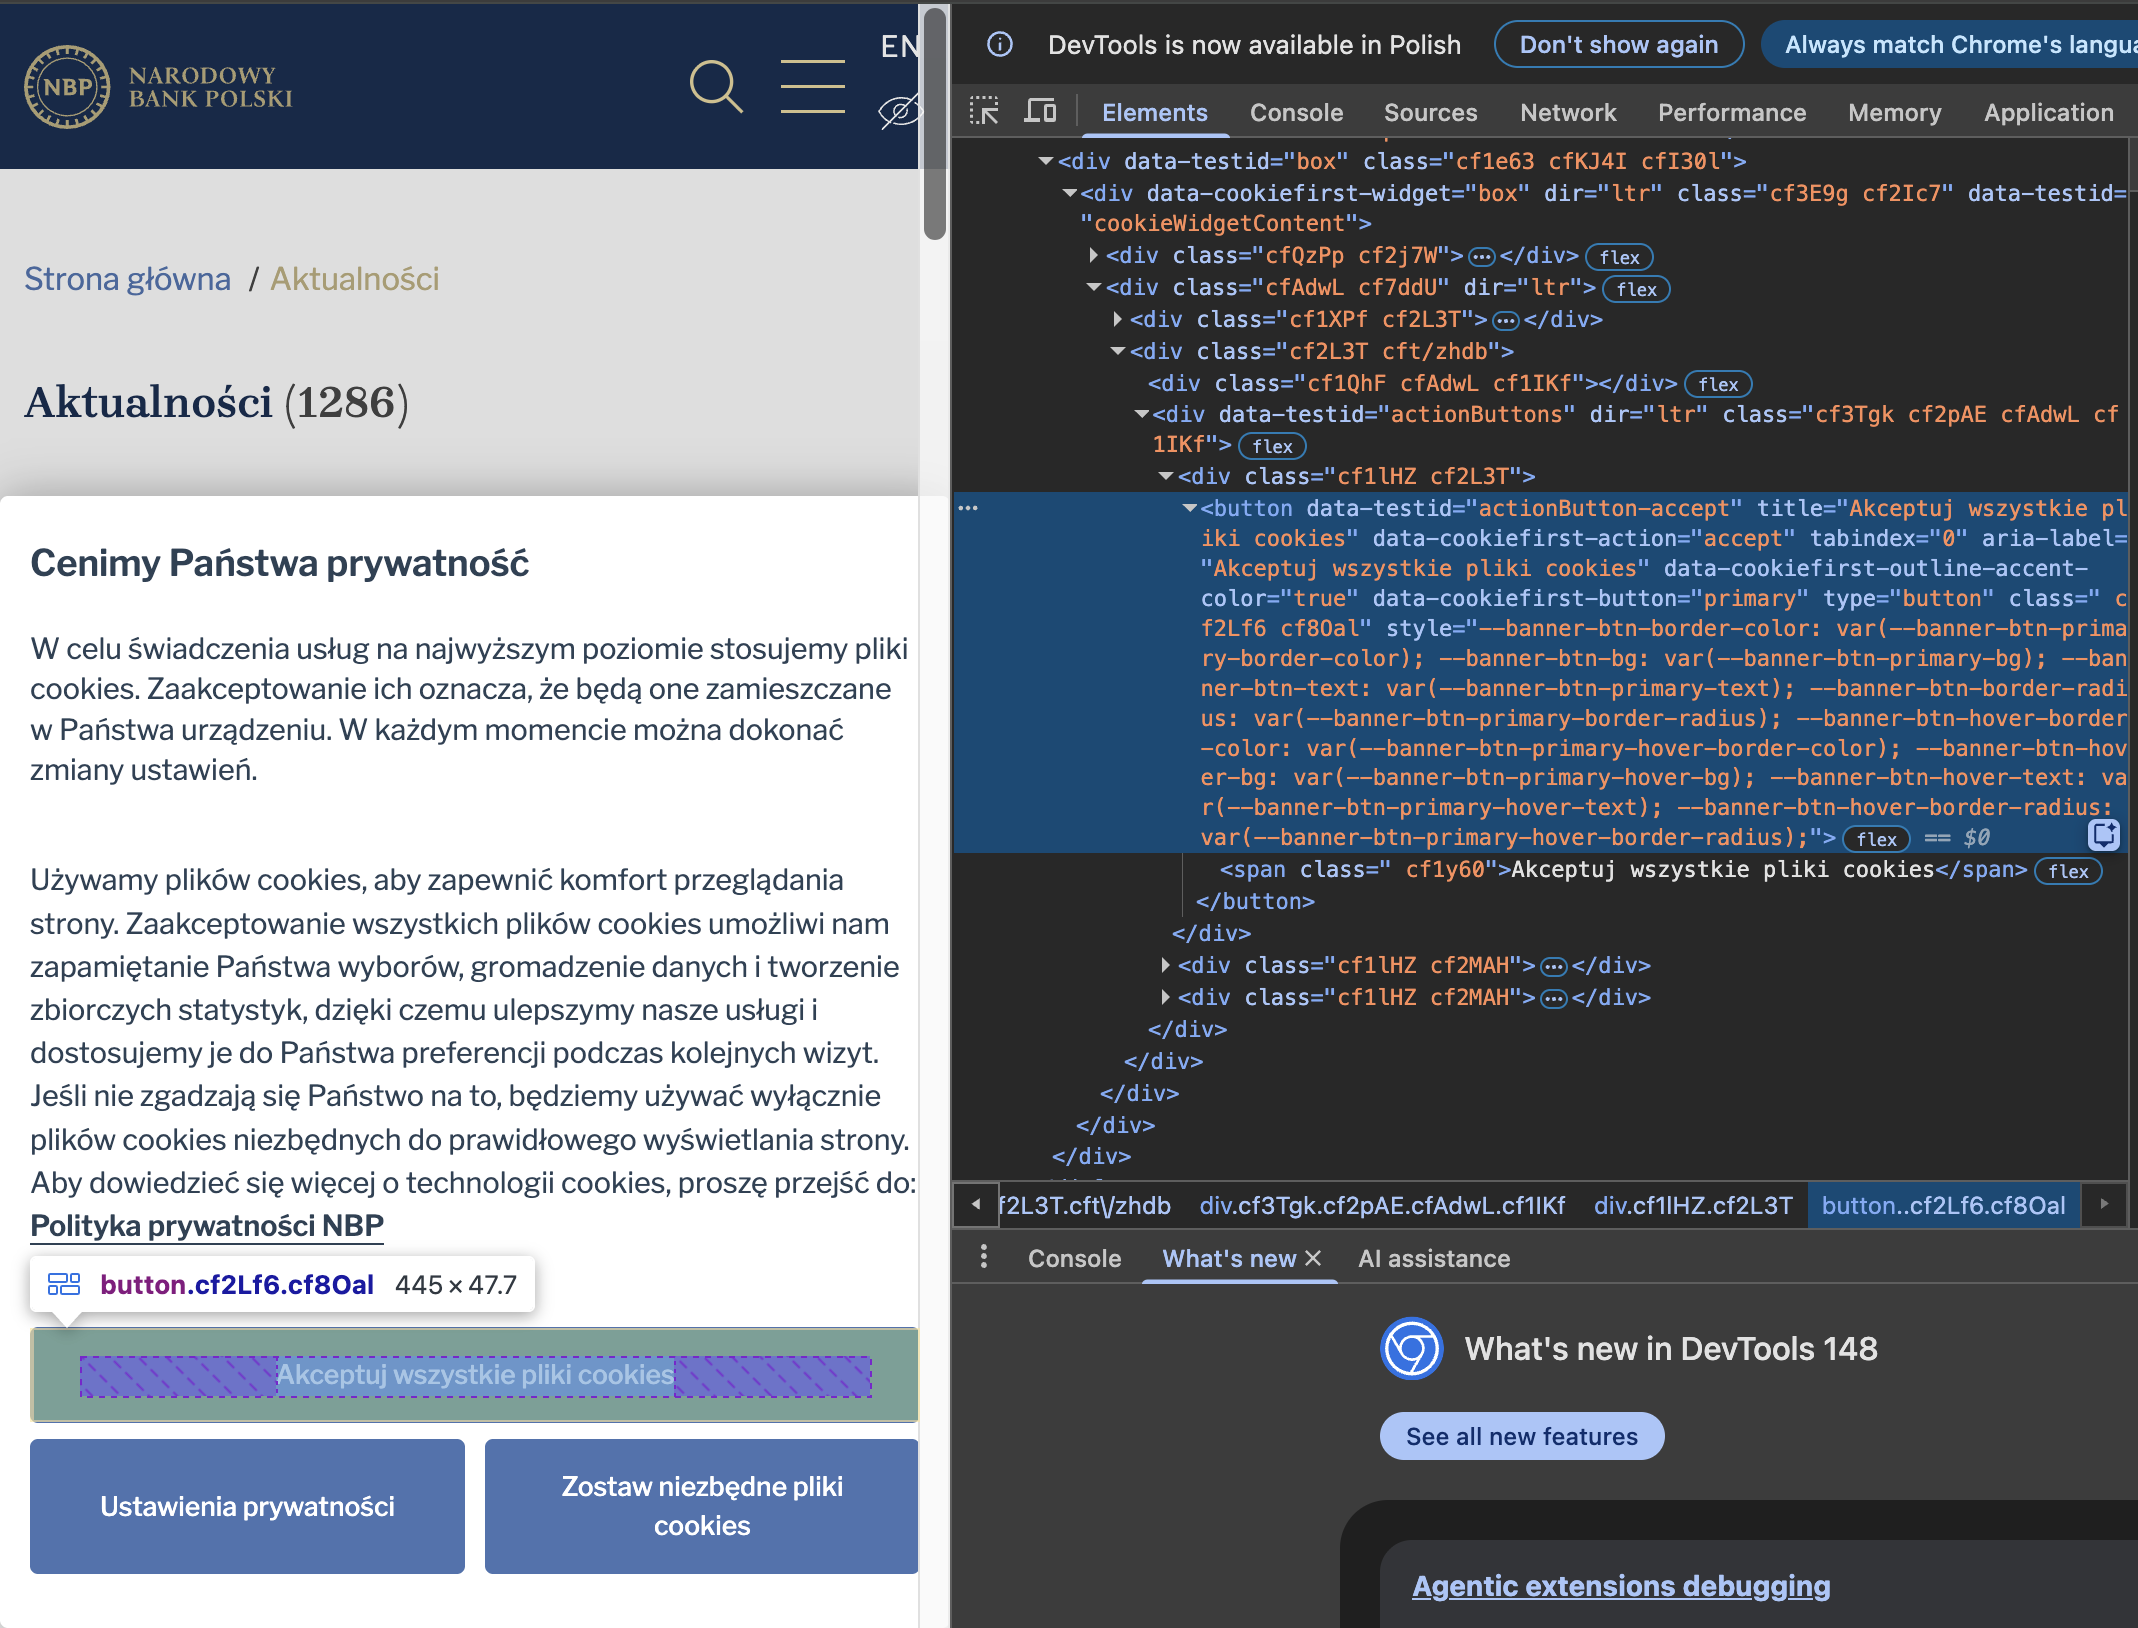

In [7]:
time.sleep(1+np.random.gamma(1,3))
cookies_button_xpath = '''//*[@data-testid="actionButton-accept"]'''
WebDriverWait(driver, 20).until(EC.visibility_of_element_located((By.XPATH, cookies_button_xpath))) 
time.sleep(1+np.random.gamma(1, 3))
content = driver.find_element("xpath", cookies_button_xpath)
content.click()

Now that we finally reached site, the idea is as follows: let's find all &lt;a hrefs&gt; on the site in the &lt;body&gt; part, then let's proceed to filter out links that do not direct us to the news but some other subpages. After examining webpage's code, it is apparent that the box containing article's title, publication date and link is contained within &lt;article class = "entry" id = ID_KEY &gt;, where ID_KEY symbolizes id value of an article.  Now, having found these parts of html code, let's save link, article name and publication date to a respective list and after that create Pandas DataFrame. 

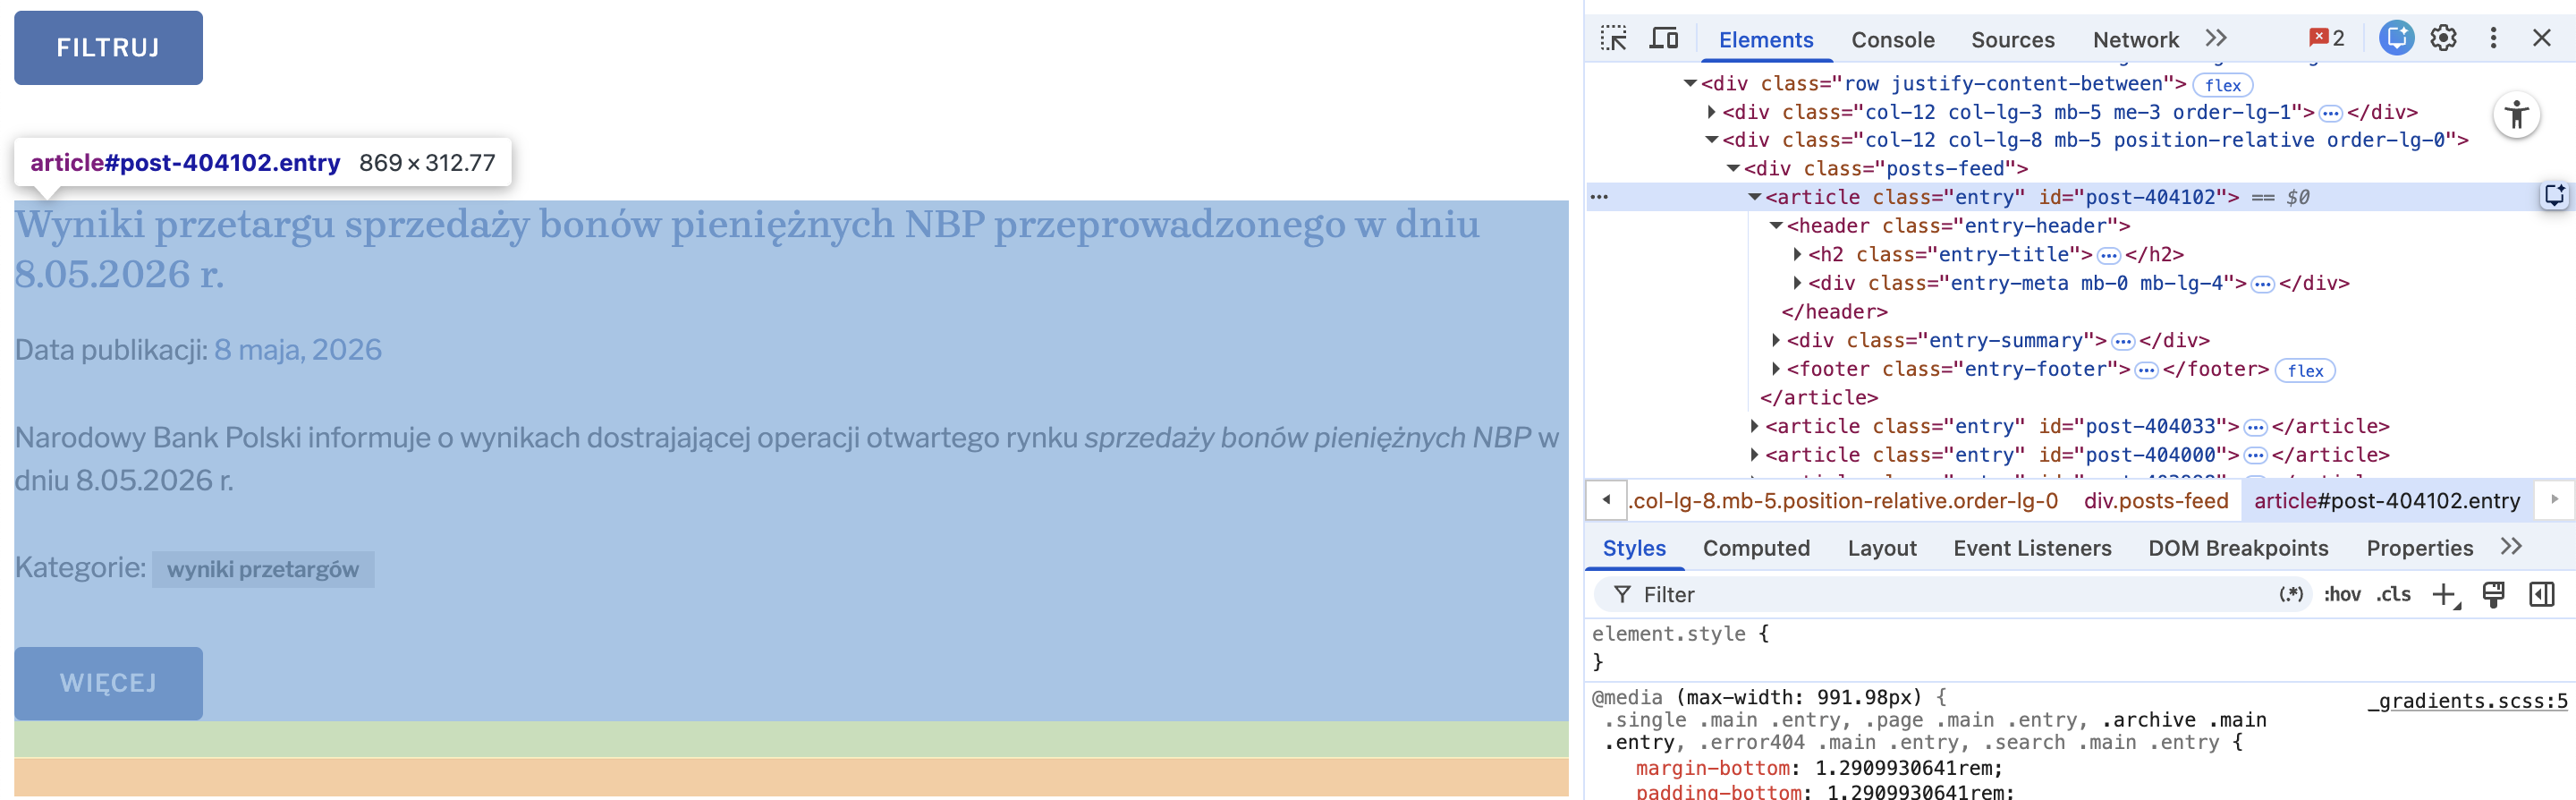


One of the challenges is that the webpage of news' archive of nbp.pl displays only 10 most recent articles, so throughout the scraping process and upon checking the content of &lt;article class="entry"&gt; it is required that the scraper proceeds to the next page of search results. Alas, next page of results isn't located on another website such as "www.nbp.pl/kategoria/aktualnosci/1", "www.nbp.pl/kategoria/aktualnosci/2" etc., but on the same page and the site only allows to click the button to execute a script of loading new results and stays on the same page "www.nbp.pl/kategoria/aktualnosci/". Another problem is that there are few cells containg &lt; a class="page link"&gt;, which is a button to load another page of results. Although it might be tempting to merely always search for the first element after &lt; li class="page item num active"&gt;, a more thorough approach of tracking the current and next page number of results in a loop was applied, after ensuring the maximum number of results' pages is 129. This approach might be used too to limit the amount of desired articles to scrape to whatever number we wish. 

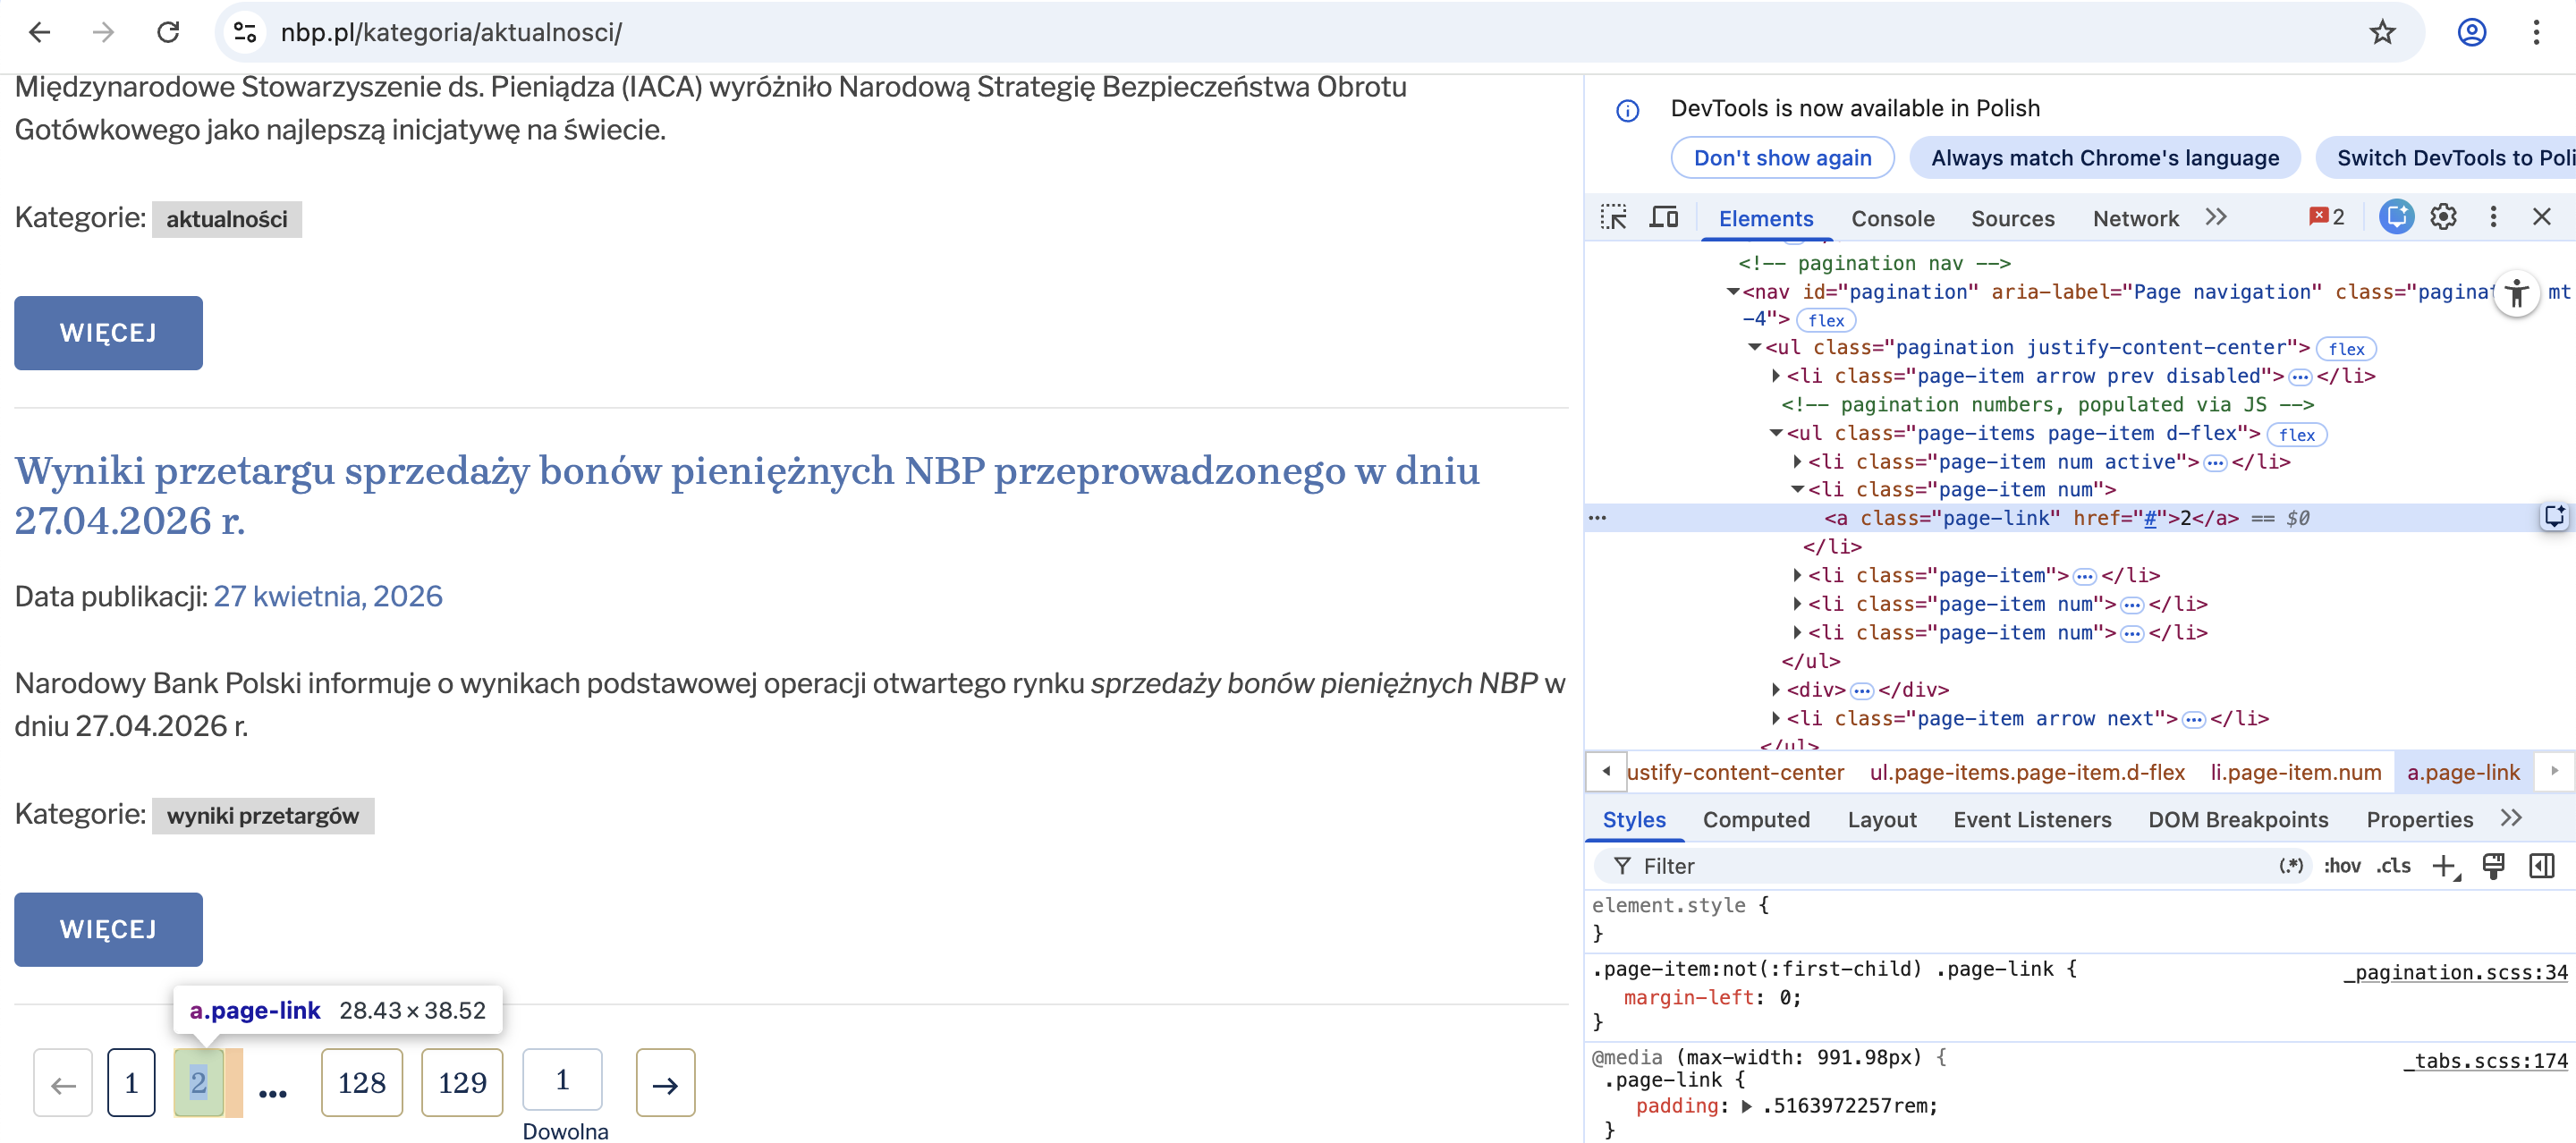

In [8]:
!if [ -e errors.log ] ; then rm errors.log ; fi
!touch errors.log

In [9]:
#lists for collected links, titles, dates, later used to create Pandas.DataFrame
hrefs = []
titles = []
dates = []
count = 0

number_of_pages_to_scrape = 129

for page in range(1,number_of_pages_to_scrape+1):
    print(f"scraping page {page}/{number_of_pages_to_scrape}")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.CLASS_NAME, "entry")))
    #refinding elements on current results' page
    tags = driver.find_elements(By.CLASS_NAME, "entry")
    
    #extracting the data from current batch
    for tag in tags:
        try:
            
            #extracting info from one element of class selenium.webdriver.remote.webelement
            title_link_element = tag.find_element(By.CSS_SELECTOR, "h2.entry-title a")
            link = title_link_element.get_attribute("href")
            title = title_link_element.text.strip()
            date_element = tag.find_element(By.CSS_SELECTOR, "time.entry-date")
            date = date_element.text.strip() 
            
            #adding to respective lists
            hrefs.append(link)
            titles.append(title)
            dates.append(date)
            
            count += 1
            #print(f"{count}: {title}")
            
        #handling exceptions so that the loop doesn't break down if any error occurs
        except Exception as e:
            print(f"Exception {e}")
            with open("errors.log", "a") as file:
                file.write(f"page {page}/{number_of_pages_to_scrape}\n")
                file.write(f"error {type(e).__name__}\n")
                file.write(f"{e}\n")

    
    #clicking the next page number in order to load next set of searches
    next_page_num = page + 1 
    
    #finishing if we scraped last site of results
    if next_page_num > number_of_pages_to_scrape:
        break

    print(f"scraped page {page + 1}, clicking button to load searches on a page {next_page_num}")
    
    try:
        
        #finding the <a> part of code with class "page-link" containting the text of our desired next page to scrape
        next_button_xpath = f"//a[contains(@class, 'page-link') and text()='{next_page_num}']"
        WebDriverWait(driver, 20).until(EC.visibility_of_element_located((By.XPATH, next_button_xpath)))
        next_button = driver.find_element(By.XPATH, next_button_xpath)
        driver.execute_script("arguments[0].scrollIntoView(true);", next_button)
        time.sleep(2 + np.random.gamma(1, 3))
        
        #clicking the next pagae button
        next_button.click()
        
        #waiting for old results to disappear and new to appear
        time.sleep(2+np.random.gamma(1, 3)) 
       
    
    #exiting the loop if an error occured
    except Exception as e:
        print(f"failed to click button for page {next_page_num}")
        with open("errors.log", "a") as file:
            file.write(f"page {page}/{number_of_pages_to_scrape}\n")
            file.write(f"error {type(e).__name__}\n")
            file.write(f"{e}\n")
        break 

print(f"job complete, scraped {len(titles)}")

scraping page 1/129
scraped page 2, clicking button to load searches on a page 2
scraping page 2/129
scraped page 3, clicking button to load searches on a page 3
scraping page 3/129
scraped page 4, clicking button to load searches on a page 4
scraping page 4/129
Exception Message: no such element: Unable to locate element: {"method":"css selector","selector":"time.entry-date"}
  (Session info: chrome=148.0.7778.97); For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#nosuchelementexception
Stacktrace:
0   chromedriver                        0x0000000100802584 cxxbridge1$str$ptr + 3225716
1   chromedriver                        0x00000001007fa45c cxxbridge1$str$ptr + 3192652
2   chromedriver                        0x00000001002bb8f4 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 75152
3   chromedriver                        0x0000000100303fe4 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unst

Now let's load our results into Pandas.DataFrame and save it in a .csv file.

In [10]:
df = pd.DataFrame({
    "titles": titles,
    "dates" : dates,
    "hrefs" : hrefs
})

In [11]:
df.to_csv("scraped_df.csv")

The following cell was made just to load the results, as the author performed the scraping and analysis on two different days, which required Jupyter to restart its kernel, which resulted in clearing all variables.

In [12]:
df = pd.read_csv("scraped_df.csv")
df = df.drop(columns = "Unnamed: 0")

The following cell is used to transform and normalize the data from columns "dates", which contain the date in a format "1 stycznia, 1970" into a pandas.Timestamp class element, so that further analysis is easier.

In [13]:
months_dict = {
    "stycznia,": 1,
    "lutego,": 2,
    "marca,": 3,
    "kwietnia,": 4,
    "maja,": 5,
    "czerwca,": 6,
    "lipca,": 7,
    "sierpnia,": 8,
    "września,": 9,
    "października,": 10,
    "listopada,": 11,
    "grudnia,": 12
}

def parse_date(date_str):
    day, month_name, year = date_str.split()

    month = months_dict[month_name]

    return pd.Timestamp(
        year=int(year),
        month=month,
        day=int(day)
    )


In [14]:
df["dates"] = df["dates"].map(parse_date)


The following is a simple function which finds regular expressions containing either "RPP" or declensed words "Rada Polityki Pieniężnej", as this notebook is aiming to find data pertaining to Monetary Policy Council and correlate it with some other economical factors found in the results. 

In [15]:
def isRPP(text):
    pattern = re.compile(r"RPP|Rad\w*\s+Polity\w*\s+Pieniężn\w*", re.IGNORECASE)
    print(pattern)
    if pattern.search(text):
        return True
    return False

In [16]:
df["titles"].map(isRPP)
df_rpp = df[df["titles"].map(isRPP)]
df_rpp

re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.compile('RPP|Rad\\w*\\s+Polity\\w*\\s+Pieniężn\\w*', re.IGNORECASE)
re.com

,titles,dates,hrefs
6,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-05-06,https://nbp.pl/rpp-06-05-2026/
7,Zmiana czerwcowego terminu posiedzenia RPP,2026-05-06,https://nbp.pl/zmiana-czerwcowego-terminu-posi...
23,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-04-09,https://nbp.pl/rpp-09-04-2026/
49,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-03-04,https://nbp.pl/rpp-04-03-2026/
64,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-02-04,https://nbp.pl/rpp-04-02-2026/
...,...,...,...
1184,Komunikat prasowy z posiedzenia RPP w dniu 5 m...,2021-05-05,https://nbp.pl/komunikat-prasowy-z-posiedzenia...
1204,Komunikat prasowy z posiedzenia RPP w dniu 7 k...,2021-04-07,https://nbp.pl/komunikat-prasowy-z-posiedzenia...
1228,Komunikat prasowy z posiedzenia RPP w dniu 3 m...,2021-03-03,https://nbp.pl/komunikat-prasowy-z-posiedzenia...
1247,Komunikat prasowy z posiedzenia RPP w dniu 3 l...,2021-02-03,https://nbp.pl/komunikat-prasowy-z-posiedzenia...


Now having found pages pertaining to Monetary Policy Council, we will be looping over them, in order to find the results of RPP's resolutions about interest rates so that their behaviour might be tracked over time. Firstly, let's create a function to describe verbally their behaviour, we will be later attributing these names it to Pandas.DataFrame df_rpp.

In [17]:
#dictionary for a more eye-pleasing evaluation
ir_movements = {
                r"podwyższyć": "raised",
                r"utrzymać": "fixed", 
                r"obniżyć": "decreased",
                r"ustaliła": "set"
                }
def ir_behaviour(text):
    behaviour = None
    for key in ir_movements:
        #this one is straightforward: compiling regex of a specific phrase so that it will be possible to apply
        #pattern matching algorithm for text on a page
        key_pattern = re.compile(key)
        if key_pattern.search(text):
            behaviour = ir_movements[key]
    return behaviour
    

Collecting proxies for the next step.


In [ ]:
'''
url_proxies = "https://sslproxies.org/"

options = webdriver.ChromeOptions()
options.add_argument("--headless")
driver = webdriver.Chrome(options = options)
driver.maximize_window()
driver.get(url_proxies)
xpath = "/html[1]/body[1]/section[1]/div[1]/div[2]/div[1]/table[1]/tbody[1]/tr[1]/td[1]"

WebDriverWait(driver, 5).until(EC.visibility_of_element_located((By.XPATH, xpath)))
time.sleep(1+np.random.gamma(1,3))

i = 1; proxy_list = []
while(True):
    try: 
        element1 = driver.find_element("xpath", "/html[1]/body[1]/section[1]/div[1]/div[2]/div[1]/table[1]/tbody[1]/tr["+str(i)+"]/td[1]")
        element2 = driver.find_element("xpath", "/html[1]/body[1]/section[1]/div[1]/div[2]/div[1]/table[1]/tbody[1]/tr["+str(i)+"]/td[2]")
        proxy_list.append(element1.text+":"+element2.text) 
        i += 1 
    except: 
        break
        
driver.close()
' '.join(proxy_list)
#takes only 10 most recent
proxy_list = proxy_list[:10]
'''


Unfortunately, when it comes to actual work, those proxies do not work well and it takes excruciatingly long to load a single link from those collected, so the step with rotating ip is ommitted. However, it worked quite well with testing ip on api64.ipify.org.

Now comes the actual cell of looping over the links. As this will require opening the page multiple times, some anti-bot detection measures will be applied. In order to elude detection, we will be faking user agent, changing device id and rotating ip via proxy. A new function to set up the whole selenium.webdriver options will be used and later applied within every iteration over the loop.

In [18]:
#current_proxy_index = 0

def randomise_driver_params():
    
    ua_or_devid_roll = np.random.rand()
    #either changing user agent or emulating mobile agent
    if ua_or_devid_roll > 0.5:
        device_id = None
        ua = UserAgent()
        user_agent = ua.random

    else:
        user_agent = None
        devices = [
            "iPhone 4", "iPhone 5", "iPhone 6 Plus", "iPhone 7", "iPhone 8 Plus",
            "iPhone 12 Pro", "Nexus 4", "Nexus 6P", "Microsoft Lumia 950", "Galaxy S5",
            "iPad Mini", "iPad Pro", "Galaxy Note 3", "BlackBerry Z30", "LG Optimus L70"
                    ]
        #doing some randomization 
        p = np.random.weibull(a = np.random.rand(), size = len(devices))
        p = p/np.sum(p)
        device_id = np.random.choice(a = devices, p = p)

    #global current_proxy_index
    #global proxy_list
    
    #proxy_address = proxy_list[current_proxy_index]
    #current_proxy_index = (current_proxy_index + 1) % len(proxy_list)

    #return user_agent, device_id, proxy_address
    return user_agent, device_id

def setup_driver(params):
    #user_agent, device_id, proxy_address = params[0], params[1], params[2]
    user_agent, device_id = params[0], params[1]
    options = webdriver.ChromeOptions()
    options.add_argument("--headless")
    if user_agent is not None:
        options.add_argument(f"user-agent={user_agent}")
    if device_id is not None:
        options.add_experimental_option("mobileEmulation", {"deviceName": device_id})
    #options.add_argument(f"--proxy-server=http://{proxy_address}")

    driver = webdriver.Chrome(options = options)

    return driver

Making sure log files do exist.

In [19]:
!if [ -e errors2.log ] ; then rm errors2.log ; fi
!touch errors2.log

Apllying all our previous functions to loop over links to pages containing info about RPP along with extracting information. In last execution of code some errors occured, although the previous version was working perfectly, so this might seem a bit messy.

In [20]:
collected_data = []

#regular expressions we will be using to find the values of certain interest rates
patterns = {
    "ir_ref": r"referencyjna\s+(\d+,\d+)%",
    "ir_lom": r"lombardowa\s+(\d+,\d+)%",
    "ir_dep": r"depozytowa\s+(\d+,\d+)%",
    "ir_red": r"redyskontowa\s+weksli\s+(\d+,\d+)%|redyskonta\s+weksli\s+(\d+,\d+)%",
    "ir_dys": r"dyskontowa\s+weksli\s+(\d+,\d+)%"
}

for i in range(len(df_rpp["hrefs"])):

    time.sleep(1 + np.random.gamma(1,3))
    href = df_rpp["hrefs"].iloc[i]

    print(f"Accessing {i}/{len(df_rpp["hrefs"])}")


    page_data = {
        "ir_behav": None,
        "ir_ref": None,
        "ir_lom": None,
        "ir_dep": None,
        "ir_red": None,
        "ir_dys": None
                }

    try:
        time.sleep(1 + np.random.gamma(1, 3))
        #covering our tracks...
        params = randomise_driver_params()
        driver = setup_driver(params)
        driver.get(href)
        wait = WebDriverWait(driver, 20)
        content_element = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, ".section__content")))
        full_text = content_element.text
        
        for key in patterns:
            match = re.search(patterns[key], full_text)
            if match:
                val_str = match.group(1).replace(',', '.')
                page_data[key] = float(val_str)

        page_data["ir_behav"] = ir_behaviour(full_text)

        print(f"Success {i}/{len(df_rpp["hrefs"])}")
        driver.close()

    except Exception as e:
        # one of my good practises after a bash course
        print(f"Error {i}/{len(df_rpp["hrefs"])}")
        with open("errors2.log", "a") as file:
            file.write(f"iteration {i}/{len(df_rpp["hrefs"])}: error {type(e).__name__}\n")
            file.write(f"{e}\n")
            file.write(f"site: {df_rpp["hrefs"].iloc[i]}\n")
        driver.close()
        continue
    collected_data.append(page_data)


Accessing 0/70
Success 0/70
Accessing 1/70
Success 1/70
Accessing 2/70
Success 2/70
Accessing 3/70
Success 3/70
Accessing 4/70
Success 4/70
Accessing 5/70
Success 5/70
Accessing 6/70
Success 6/70
Accessing 7/70
Success 7/70
Accessing 8/70
Success 8/70
Accessing 9/70
Success 9/70
Accessing 10/70
Success 10/70
Accessing 11/70
Success 11/70
Accessing 12/70
Success 12/70
Accessing 13/70
Success 13/70
Accessing 14/70
Success 14/70
Accessing 15/70
Success 15/70
Accessing 16/70
Success 16/70
Accessing 17/70
Success 17/70
Accessing 18/70
Success 18/70
Accessing 19/70
Success 19/70
Accessing 20/70
Success 20/70
Accessing 21/70
Success 21/70
Accessing 22/70
Success 22/70
Accessing 23/70
Success 23/70
Accessing 24/70
Success 24/70
Accessing 25/70
Success 25/70
Accessing 26/70
Success 26/70
Accessing 27/70
Success 27/70
Accessing 28/70
Success 28/70
Accessing 29/70
Success 29/70
Accessing 30/70
Success 30/70
Accessing 31/70
Success 31/70
Accessing 32/70
Success 32/70
Accessing 33/70
Success 33/70


/var/folders/qy/kt353w5x2rz674xc3bg0m4q00000gn/T/ipykernel_15095/1909071072.py:21: RuntimeWarning: invalid value encountered in divide
  p = p/np.sum(p)


Error 67/70


InvalidSessionIdException: Message: invalid session id; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
0   chromedriver                        0x00000001005a6584 cxxbridge1$str$ptr + 3225716
1   chromedriver                        0x000000010059e45c cxxbridge1$str$ptr + 3192652
2   chromedriver                        0x000000010005f6f8 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 74644
3   chromedriver                        0x000000010009cd10 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 326060
4   chromedriver                        0x00000001000c3798 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 484404
5   chromedriver                        0x00000001000c3080 _RNvCsiKAbIcglKMQ_7___rustc35___rust_no_alloc_shim_is_unstable_v2 + 482588
6   chromedriver                        0x000000010002cab8 chromedriver + 11

Now let's create a Pandas.DataFrame out of collected data and match it with our links. 

In [21]:
df_interest_rates = pd.DataFrame(collected_data)
df_rpp = pd.concat([df_rpp.reset_index(drop=True), df_interest_rates], axis=1)



As expected, some elements of the table don't have interest rates, as the article might have been about another subject. Having examined closer, the table has an empty column in "ir_red" up to the date of 04.01.2023. This made me recheck the articles by hand in this edge case and it became apparent, that up to 2023 nbp.pl used "stopa redyskonta" and since 2023 "stopa redyskontowa", which forced me to modify regex matching that interest_rate. 

In [22]:
df_rpp.to_csv("df_rpp.csv")
df_rpp

,titles,dates,hrefs,ir_behav,ir_ref,ir_lom,ir_dep,ir_red,ir_dys
0,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-05-06,https://nbp.pl/rpp-06-05-2026/,fixed,3.75,4.25,3.25,3.80,3.80
1,Zmiana czerwcowego terminu posiedzenia RPP,2026-05-06,https://nbp.pl/zmiana-czerwcowego-terminu-posi...,NaN,NaN,NaN,NaN,NaN,NaN
2,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-04-09,https://nbp.pl/rpp-09-04-2026/,fixed,3.75,4.25,3.25,3.80,3.80
3,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-03-04,https://nbp.pl/rpp-04-03-2026/,decreased,3.75,4.25,3.25,3.80,3.80
4,Komunikat prasowy z posiedzenia Rady Polityki ...,2026-02-04,https://nbp.pl/rpp-04-02-2026/,fixed,4.00,4.50,3.50,4.05,4.05
...,...,...,...,...,...,...,...,...,...
65,Komunikat prasowy z posiedzenia RPP w dniu 5 m...,2021-05-05,https://nbp.pl/komunikat-prasowy-z-posiedzenia...,NaN,NaN,NaN,NaN,NaN,NaN
66,Komunikat prasowy z posiedzenia RPP w dniu 7 k...,2021-04-07,https://nbp.pl/komunikat-prasowy-z-posiedzenia...,NaN,NaN,NaN,NaN,NaN,NaN
67,Komunikat prasowy z posiedzenia RPP w dniu 3 m...,2021-03-03,https://nbp.pl/komunikat-prasowy-z-posiedzenia...,NaN,NaN,NaN,NaN,NaN,NaN
68,Komunikat prasowy z posiedzenia RPP w dniu 3 l...,2021-02-03,https://nbp.pl/komunikat-prasowy-z-posiedzenia...,NaN,NaN,NaN,NaN,NaN,NaN


Now let's see the effects on the plot.

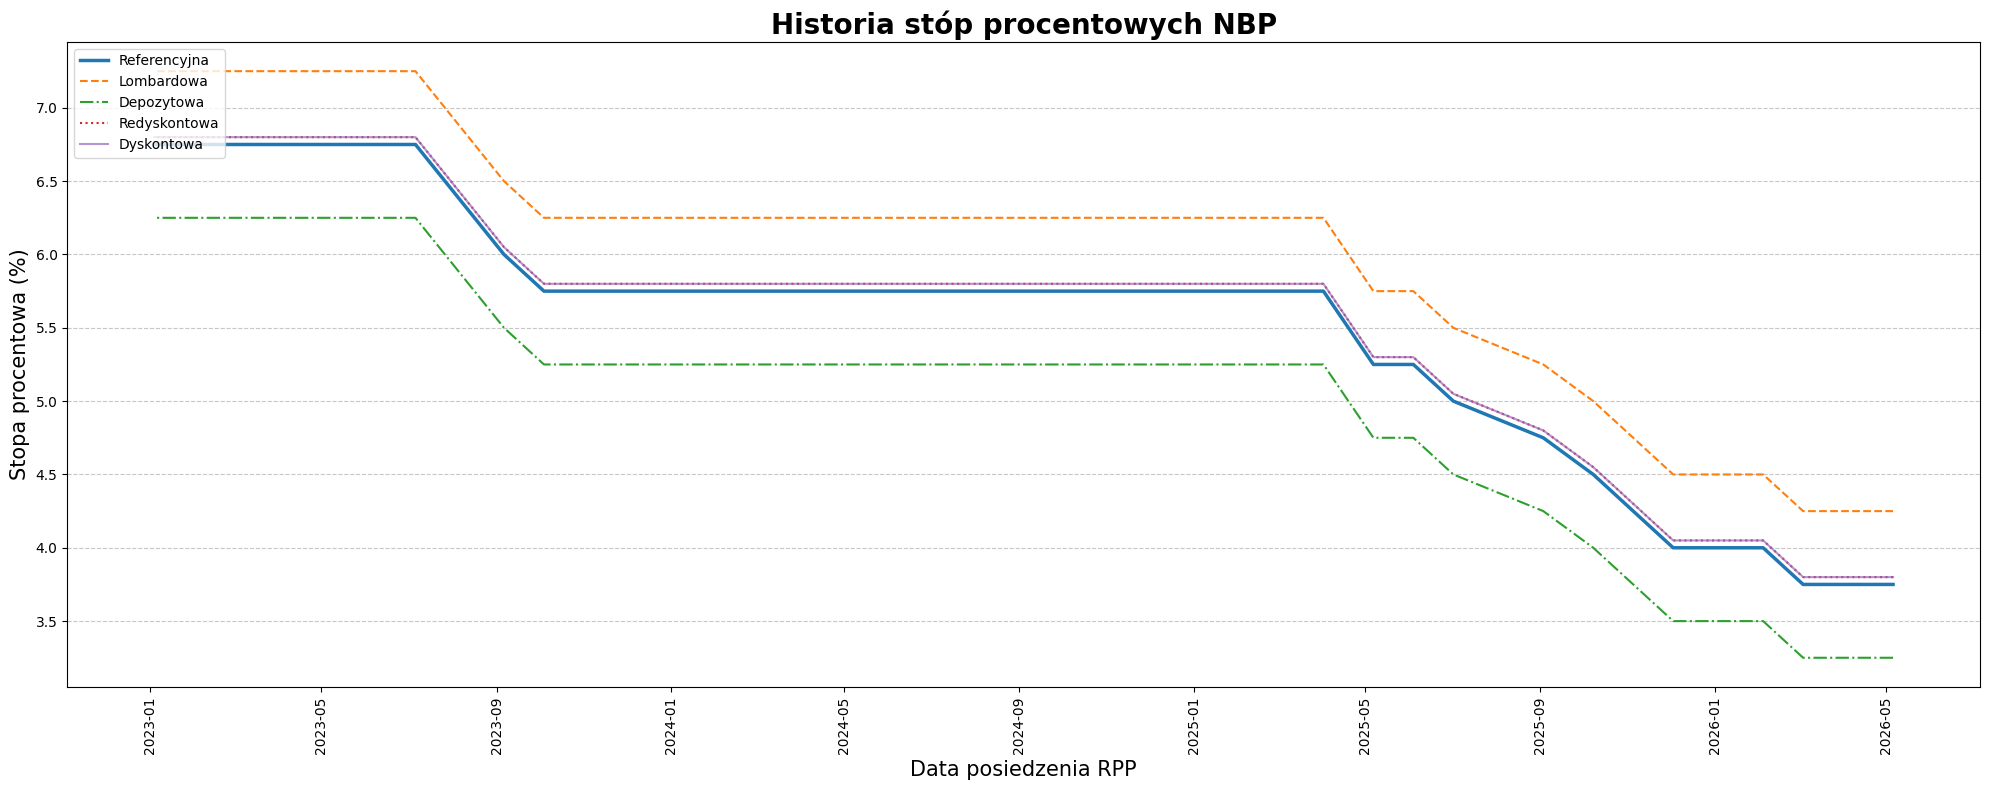

In [23]:
df_rpp_drawing = df_rpp.dropna(subset = ["ir_ref","ir_lom", "ir_dep", "ir_red", "ir_dys"])
plt.figure(figsize=(20, 8))
plt.plot(df_rpp_drawing["dates"], df_rpp_drawing["ir_ref"], label="Referencyjna",linewidth=2.5)
plt.plot(df_rpp_drawing["dates"], df_rpp_drawing["ir_lom"], label="Lombardowa", linestyle='--')
plt.plot(df_rpp_drawing["dates"], df_rpp_drawing["ir_dep"], label="Depozytowa", linestyle='-.')
plt.plot(df_rpp_drawing["dates"], df_rpp_drawing["ir_red"], label="Redyskontowa", linestyle=':')
plt.plot(df_rpp_drawing["dates"], df_rpp_drawing["ir_dys"], label="Dyskontowa", alpha=0.7)
plt.title("Historia stóp procentowych NBP", fontsize=20, fontweight='bold')
plt.xlabel("Data posiedzenia RPP", fontsize=15)
plt.ylabel("Stopa procentowa (%)", fontsize=15)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

Now let's compare it with a screenshot of a plot from https://nbp.pl/statystyka-i-sprawozdawczosc/podstawowe-wykresy/ . As we can see, the plots are identical, within an accuracy of difference of plot visualization. Unfortunately, last execution of code left something with errors although previous version were working nicely so with no time to debug it properly and rerun code, the version of files attached in already executed code in notebook will give the impression of being incomplete.

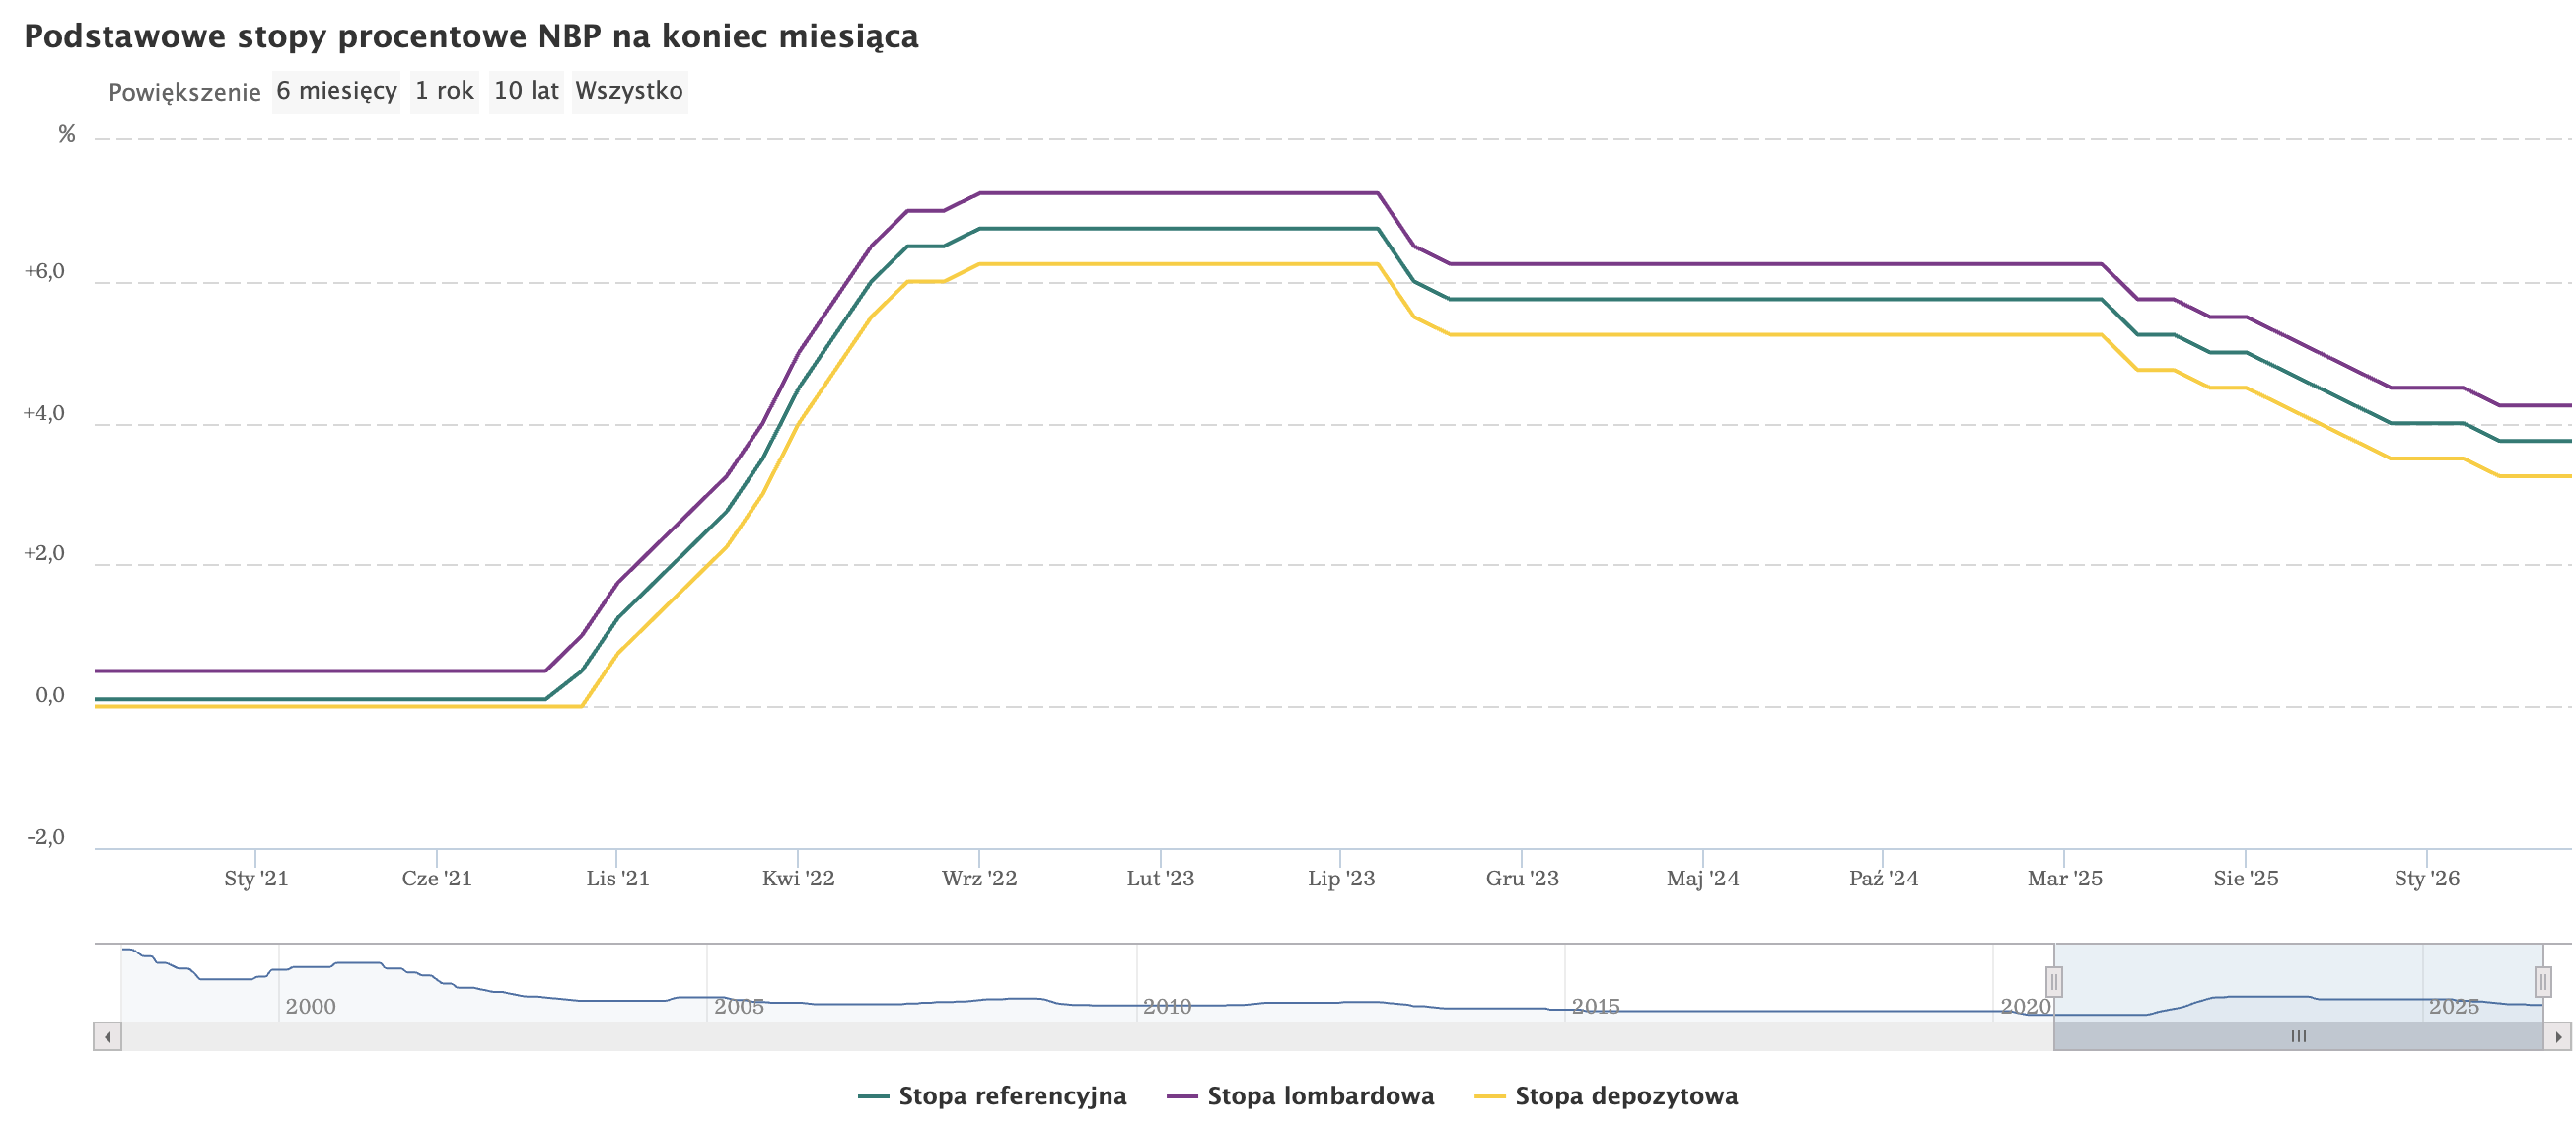